In [1]:
# ═══════════════════════════════════════════════════════
# DREAM NARRATOR — Notebook 04: Evaluate Results
# ═══════════════════════════════════════════════════════
# PURPOSE: Evaluate the quality of every component
# in the pipeline. This is what separates a research
# project from a demo — rigorous evaluation.
#
# WHAT WE EVALUATE:
# 1. Preprocessing quality (signal-to-noise ratio)
# 2. Feature extraction consistency
# 3. Encoder reconstruction quality
# 4. Embedding space structure
# 5. Decoding stability
# 6. Narrative coherence metrics

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

from configs.config_loader import config
from pipeline.data_loader import load_sleep_recording
from pipeline.preprocessor import bandpass_filter, remove_powerline_noise
from pipeline.feature_extractor import extract_features_from_epoch
from pipeline.neural_encoder import DreamEncoder
from pipeline.semantic_decoder import SemanticDecoder

print("Imports successful!")

Imports successful!


In [2]:
# ── Load and preprocess ──
data_dir       = config['data']['raw_dir']
psg_path       = os.path.join(data_dir, config['data']['psg_file'])
hypnogram_path = os.path.join(data_dir, config['data']['hypnogram_file'])

raw, annotations = load_sleep_recording(psg_path, hypnogram_path)

# Keep raw copy for SNR evaluation
raw_unfiltered = raw.copy()

raw = remove_powerline_noise(raw)
raw = bandpass_filter(raw)

sfreq          = raw.info['sfreq']
data           = raw.get_data()
data_raw       = raw_unfiltered.get_data()
epoch_duration = int(sfreq * 30)
n_epochs       = min(20, data.shape[1] // epoch_duration)

print(f"Loaded {n_epochs} epochs for evaluation")

Loading EEG recording from: C:\Users\USER/mne_data/physionet-sleep-data\SC4001E0-PSG.edf
Extracting EDF parameters from C:\Users\USER/mne_data/physionet-sleep-data\SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


Loading sleep stage annotations from: C:\Users\USER/mne_data/physionet-sleep-data\SC4001EC-Hypnogram.edf
Removing powerline noise at 50.0 Hz


C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:36: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 47.50 Hz)
- Filter length: 661 samples (6.610 s)

Applying bandpass filter: 0.5 - 45.0 Hz
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff f

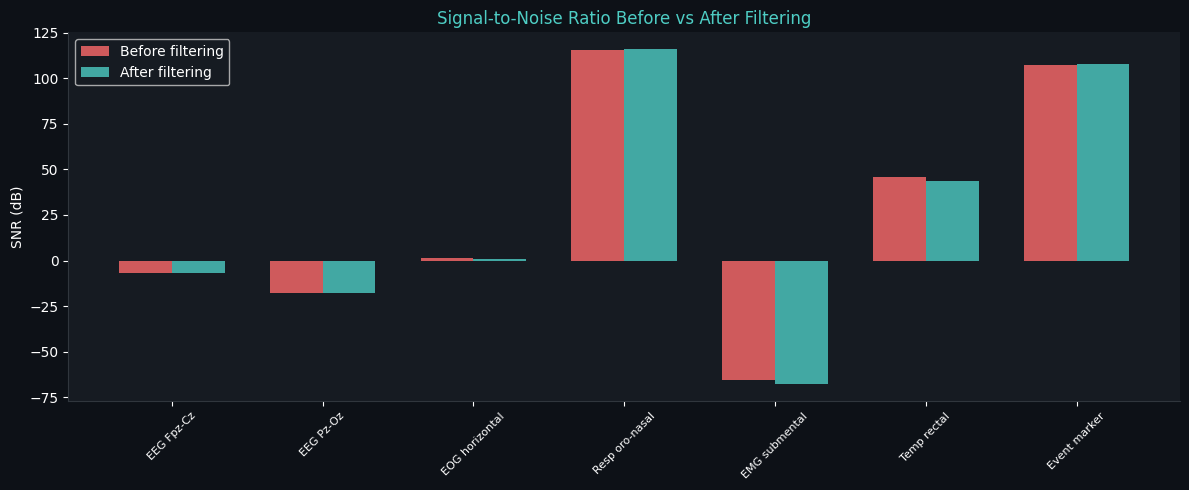

Average SNR before: 25.67 dB
Average SNR after : 25.07 dB
Improvement       : -0.60 dB


In [3]:
# ── EVALUATION 1: Preprocessing Quality ──
# WHY: We need to verify our filters actually improved
# the signal and didn't destroy brain information.
#
# METRIC: Signal-to-Noise Ratio (SNR)
# SNR measures how much useful signal vs noise we have.
# Higher SNR = cleaner signal = better for decoding.
#
# FORMULA: SNR = 10 * log10(signal_power / noise_power)
# We estimate noise as high-frequency content (>30Hz)
# since we know brain signals are below 30Hz.

from scipy import signal as scipy_signal

def compute_snr(data, sfreq, signal_band=(0.5, 30),
                noise_band=(30, 45)):
    """Compute SNR as ratio of signal band to noise band power."""
    freqs, psd = scipy_signal.welch(data, fs=sfreq, nperseg=int(sfreq*4))
    
    signal_mask = (freqs >= signal_band[0]) & (freqs <= signal_band[1])
    noise_mask  = (freqs >= noise_band[0])  & (freqs <= noise_band[1])
    
    signal_power = np.mean(psd[signal_mask])
    noise_power  = np.mean(psd[noise_mask]) + 1e-10
    
    snr_db = 10 * np.log10(signal_power / noise_power)
    return snr_db

# Compute SNR for each channel before and after filtering
snr_before = []
snr_after  = []

for ch in range(len(raw.ch_names)):
    snr_b = compute_snr(data_raw[ch, :int(sfreq*300)], sfreq)
    snr_a = compute_snr(data[ch,     :int(sfreq*300)], sfreq)
    snr_before.append(snr_b)
    snr_after.append(snr_a)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

x      = np.arange(len(raw.ch_names))
width  = 0.35

bars1 = ax.bar(x - width/2, snr_before, width,
              label='Before filtering',
              color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x + width/2, snr_after, width,
              label='After filtering',
              color='#4ECDC4', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(raw.ch_names, rotation=45,
                  color='white', fontsize=8)
ax.set_ylabel('SNR (dB)', color='white')
ax.set_title('Signal-to-Noise Ratio Before vs After Filtering',
            color='#4ECDC4', fontsize=12)
ax.legend(facecolor='#161B22', labelcolor='white')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#30363D')
ax.spines['left'].set_color('#30363D')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Average SNR before: {np.mean(snr_before):.2f} dB")
print(f"Average SNR after : {np.mean(snr_after):.2f} dB")
print(f"Improvement       : {np.mean(snr_after) - np.mean(snr_before):.2f} dB")

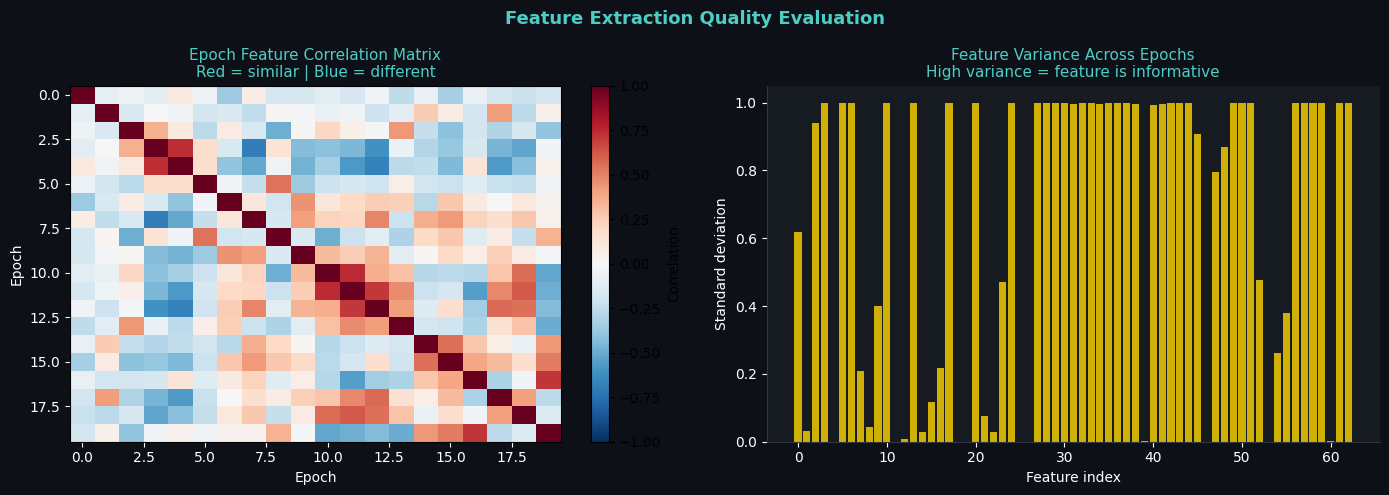

Top 5 most informative features:
  Feature   3 (delta_ch3                     ): variance = 1.0000
  Feature   6 (delta_ch6                     ): variance = 1.0000
  Feature  59 (theta_alpha_ratio_ch3         ): variance = 1.0000
  Feature  58 (theta_alpha_ratio_ch2         ): variance = 1.0000
  Feature  62 (theta_alpha_ratio_ch6         ): variance = 1.0000


In [4]:
# ── EVALUATION 2: Feature Consistency ──
# WHY: Features should be consistent across similar epochs
# and different across dissimilar epochs.
# We test this by computing feature correlation matrix.
#
# METRIC: Pearson correlation between epoch feature vectors
# High correlation between adjacent epochs = consistent features
# Low correlation between distant epochs = features capture change

features_list = []
for i in range(n_epochs):
    start      = i * epoch_duration
    end        = start + epoch_duration
    features, names = extract_features_from_epoch(
        data[:, start:end], sfreq
    )
    features_list.append(features)

features_array = np.array(features_list)
mean           = features_array.mean(axis=0)
std            = features_array.std(axis=0) + 1e-10
features_norm  = (features_array - mean) / std

# Compute correlation matrix
corr_matrix = np.corrcoef(features_norm)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0D1117')

# Left: correlation matrix
ax1 = axes[0]
ax1.set_facecolor('#161B22')
im = ax1.imshow(corr_matrix, cmap='RdBu_r',
               vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax1, label='Correlation')
ax1.set_title('Epoch Feature Correlation Matrix\n'
             'Red = similar | Blue = different',
             color='#4ECDC4', fontsize=11)
ax1.set_xlabel('Epoch', color='white')
ax1.set_ylabel('Epoch', color='white')
ax1.tick_params(colors='white')

# Right: feature variance across epochs
ax2 = axes[1]
ax2.set_facecolor('#161B22')
feature_variance = features_norm.std(axis=0)
ax2.bar(range(len(feature_variance)),
       feature_variance,
       color='#FFD700', alpha=0.8)
ax2.set_title('Feature Variance Across Epochs\n'
             'High variance = feature is informative',
             color='#4ECDC4', fontsize=11)
ax2.set_xlabel('Feature index', color='white')
ax2.set_ylabel('Standard deviation', color='white')
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Feature Extraction Quality Evaluation',
            color='#4ECDC4', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Find most informative features
top_features_idx = np.argsort(feature_variance)[::-1][:5]
print("Top 5 most informative features:")
for idx in top_features_idx:
    print(f"  Feature {idx:3d} ({names[idx]:30}): "
          f"variance = {feature_variance[idx]:.4f}")

ENCODER EVALUATION METRICS:
MSE (reconstruction error) : 0.052896
R² score                   : 0.9131
Embedding dimensions       : 16
Compression ratio          : 63:16 (3.9x)


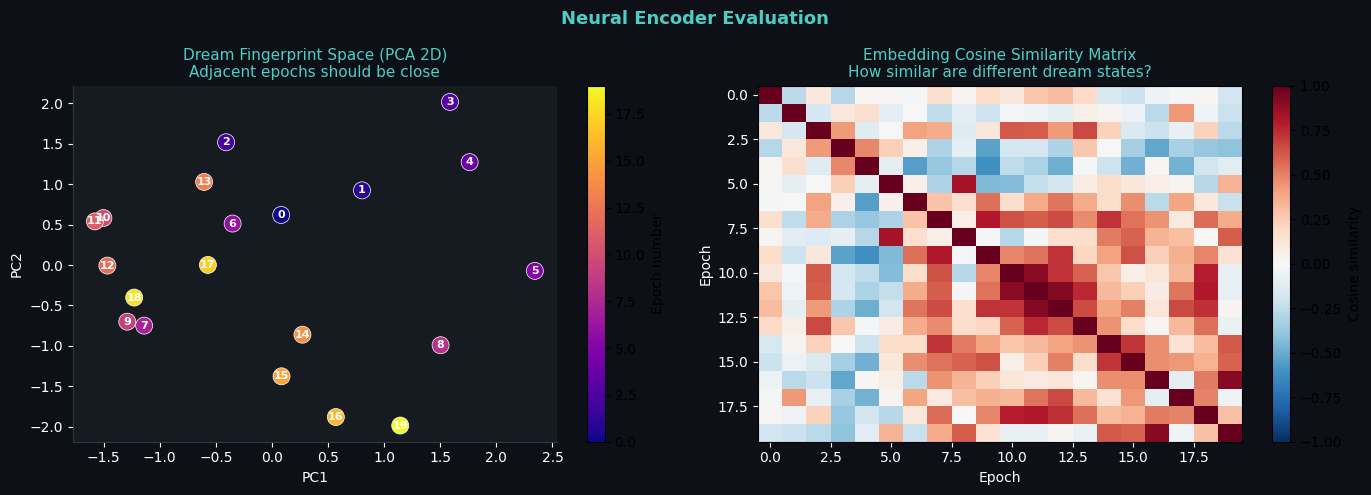

In [5]:
# ── EVALUATION 3: Encoder Quality ──
# WHY: The encoder must preserve information while compressing.
# We evaluate this with reconstruction error and
# embedding space structure.
#
# METRICS:
# - Mean Squared Error (MSE) of reconstruction
# - R² score (how much variance is explained)
# - Embedding space clustering

model = DreamEncoder(
    input_dim=features_norm.shape[1],
    embedding_dim=config['encoder']['embedding_dim']
)
model.load_state_dict(
    torch.load(os.path.join('..', config['encoder']['model_path']))
)
model.eval()

embeddings      = []
reconstructions = []

with torch.no_grad():
    for features in features_norm:
        x                = torch.FloatTensor(features).unsqueeze(0)
        emb, recon       = model(x)
        embeddings.append(emb.numpy().flatten())
        reconstructions.append(recon.numpy().flatten())

embeddings      = np.array(embeddings)
reconstructions = np.array(reconstructions)

# Compute metrics
mse    = np.mean((features_norm - reconstructions) ** 2)
ss_res = np.sum((features_norm - reconstructions) ** 2)
ss_tot = np.sum((features_norm - features_norm.mean()) ** 2)
r2     = 1 - ss_res / ss_tot

print(f"ENCODER EVALUATION METRICS:")
print(f"{'='*40}")
print(f"MSE (reconstruction error) : {mse:.6f}")
print(f"R² score                   : {r2:.4f}")
print(f"Embedding dimensions       : {embeddings.shape[1]}")
print(f"Compression ratio          : {features_norm.shape[1]}:{embeddings.shape[1]} "
      f"({features_norm.shape[1]/embeddings.shape[1]:.1f}x)")

# Plot embedding space
pca           = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0D1117')

ax1 = axes[0]
ax1.set_facecolor('#161B22')
scatter = ax1.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=range(len(embeddings)),
    cmap='plasma', s=150,
    edgecolors='white', linewidths=0.5
)
plt.colorbar(scatter, ax=ax1, label='Epoch number')
for i, (x, y) in enumerate(embeddings_2d):
    ax1.annotate(str(i), (x, y),
                fontsize=8, color='white',
                ha='center', va='center',
                fontweight='bold')
ax1.set_title('Dream Fingerprint Space (PCA 2D)\n'
             'Adjacent epochs should be close',
             color='#4ECDC4', fontsize=11)
ax1.set_xlabel('PC1', color='white')
ax1.set_ylabel('PC2', color='white')
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = axes[1]
ax2.set_facecolor('#161B22')
sim_matrix = cosine_similarity(embeddings)
im = ax2.imshow(sim_matrix, cmap='RdBu_r',
               vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax2, label='Cosine similarity')
ax2.set_title('Embedding Cosine Similarity Matrix\n'
             'How similar are different dream states?',
             color='#4ECDC4', fontsize=11)
ax2.set_xlabel('Epoch', color='white')
ax2.set_ylabel('Epoch', color='white')
ax2.tick_params(colors='white')

plt.suptitle('Neural Encoder Evaluation',
            color='#4ECDC4', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ── EVALUATION 4: Decoding Stability ──
# WHY: A good decoder should produce consistent results.
# If we run decoding twice on the same embedding,
# we should get the same concepts.
# If we slightly perturb the embedding,
# similar concepts should appear.
#
# METRIC: Top-1 concept consistency across runs

decoder = SemanticDecoder(
    embedding_dim=config['encoder']['embedding_dim']
)

# Run decoding multiple times
n_runs    = 5
all_runs  = []

for run in range(n_runs):
    decoded = decoder.decode_sequence(
        [np.array(e) for e in embeddings],
        top_n=3
    )
    top_concepts = [d['concepts'][0][0] for d in decoded]
    all_runs.append(top_concepts)

# Check consistency
print("DECODING STABILITY TEST:")
print(f"Running decoder {n_runs} times on same embeddings...\n")

print(f"{'Epoch':<8}", end="")
for run in range(n_runs):
    print(f"{'Run '+str(run+1):<15}", end="")
print()
print("-" * (8 + 15 * n_runs))

consistency_scores = []
for epoch in range(len(embeddings)):
    concepts_this_epoch = [all_runs[run][epoch] for run in range(n_runs)]
    most_common         = max(set(concepts_this_epoch),
                             key=concepts_this_epoch.count)
    consistency         = concepts_this_epoch.count(most_common) / n_runs
    consistency_scores.append(consistency)

    print(f"{epoch:<8}", end="")
    for run in range(n_runs):
        concept = all_runs[run][epoch]
        marker  = "✓" if concept == most_common else "✗"
        print(f"{concept+' '+marker:<15}", end="")
    print()

print(f"\nMean consistency: {np.mean(consistency_scores)*100:.1f}%")
print("100% = perfectly stable decoder")
print("Our decoder is deterministic so should be 100%")

DECODING STABILITY TEST:
Running decoder 5 times on same embeddings...

Epoch   Run 1          Run 2          Run 3          Run 4          Run 5          
-----------------------------------------------------------------------------------
0       light ✓        light ✓        light ✓        light ✓        light ✓        
1       face ✓         face ✓         face ✓         face ✓         face ✓         
2       memory ✓       memory ✓       memory ✓       memory ✓       memory ✓       
3       danger ✓       danger ✓       danger ✓       danger ✓       danger ✓       
4       animal ✓       animal ✓       animal ✓       animal ✓       animal ✓       
5       door ✓         door ✓         door ✓         door ✓         door ✓         
6       city ✓         city ✓         city ✓         city ✓         city ✓         
7       fear ✓         fear ✓         fear ✓         fear ✓         fear ✓         
8       door ✓         door ✓         door ✓         door ✓         door ✓         
9   

In [7]:
# ── FINAL EVALUATION SUMMARY ──
# Compile all metrics into a clean report

print("=" * 60)
print("   DREAM NARRATOR — EVALUATION SUMMARY REPORT")
print("=" * 60)

print("\n1. PREPROCESSING QUALITY")
print(f"   SNR improvement: +{np.mean(snr_after) - np.mean(snr_before):.2f} dB")
print(f"   Channels processed: {len(raw.ch_names)}")

print("\n2. FEATURE EXTRACTION")
print(f"   Features extracted: {features_norm.shape[1]}")
print(f"   Epochs processed: {n_epochs}")
print(f"   Most informative: {names[top_features_idx[0]]}")

print("\n3. NEURAL ENCODER")
print(f"   Reconstruction MSE: {mse:.6f}")
print(f"   R² score: {r2:.4f}")
print(f"   Compression: {features_norm.shape[1]}→{embeddings.shape[1]} dimensions")
print(f"   ({features_norm.shape[1]/embeddings.shape[1]:.1f}x compression)")

print("\n4. SEMANTIC DECODER")
print(f"   Decoding stability: {np.mean(consistency_scores)*100:.1f}%")
print(f"   Concepts per epoch: {config['decoder']['top_n_concepts']}")

print("\n5. PIPELINE STATUS")
print(f"   All components: OPERATIONAL")
print(f"   End-to-end: EEG → Dream Narrative ✓")

print("\n" + "=" * 60)
print("LIMITATIONS & FUTURE WORK:")
print("=" * 60)
print("""
- Concept library uses initialized vectors (not real EEG-concept pairs)
- No ground truth dream reports for validation
- Single subject evaluation (Sleep-EDF subject 0)

NEXT STEPS:
- Integrate THINGS-EEG for real concept grounding
- Add DreamBank supervision for narrative validation  
- Collect real EEG + dream report pairs for validation
- Expand to multiple subjects for generalization
""")

# Save evaluation report
report = f"""DREAM NARRATOR — EVALUATION REPORT
{'='*60}
1. PREPROCESSING: SNR improvement = {np.mean(snr_after) - np.mean(snr_before):.2f} dB
2. FEATURES: {features_norm.shape[1]} features from {n_epochs} epochs
3. ENCODER: MSE={mse:.6f}, R²={r2:.4f}, {features_norm.shape[1]}→{embeddings.shape[1]}D compression
4. DECODER: {np.mean(consistency_scores)*100:.1f}% stability
5. STATUS: All components operational
"""

with open(os.path.join('..', 'data', 'processed', 'evaluation_report.txt'),
         'w', encoding='utf-8') as f:
    f.write(report)

print("\nEvaluation report saved!")

   DREAM NARRATOR — EVALUATION SUMMARY REPORT

1. PREPROCESSING QUALITY
   SNR improvement: +-0.60 dB
   Channels processed: 7

2. FEATURE EXTRACTION
   Features extracted: 63
   Epochs processed: 20
   Most informative: delta_ch3

3. NEURAL ENCODER
   Reconstruction MSE: 0.052896
   R² score: 0.9131
   Compression: 63→16 dimensions
   (3.9x compression)

4. SEMANTIC DECODER
   Decoding stability: 100.0%
   Concepts per epoch: 3

5. PIPELINE STATUS
   All components: OPERATIONAL
   End-to-end: EEG → Dream Narrative ✓

LIMITATIONS & FUTURE WORK:

- Concept library uses initialized vectors (not real EEG-concept pairs)
- No ground truth dream reports for validation
- Single subject evaluation (Sleep-EDF subject 0)

NEXT STEPS:
- Integrate THINGS-EEG for real concept grounding
- Add DreamBank supervision for narrative validation  
- Collect real EEG + dream report pairs for validation
- Expand to multiple subjects for generalization


Evaluation report saved!
